In [2]:
# ── 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

df = pd.read_csv('../Level1 Task2_EDA/Amazon Sale Report.csv', low_memory=False)

df = df.dropna(subset=['Amount', 'Qty', 'Status'])
df = df[df['Amount'] > 0]
df = df[df['Qty'] > 0]

print("Shape:", df.shape)
print(df['Status'].value_counts())

Shape: (113701, 24)
Status
Shipped                          76078
Shipped - Delivered to Buyer     28045
Cancelled                         5630
Shipped - Returned to Seller      1899
Shipped - Picked Up                945
Pending                            639
Pending - Waiting for Pick Up      272
Shipped - Returning to Seller      143
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            3
Shipped - Damaged                    1
Name: count, dtype: int64


In [3]:
# ── 2. Create Target Variable ─────────────────────────────────
df['Target'] = df['Status'].apply(
    lambda x: 1 if 'Shipped' in str(x) else 0
)

print("Target distribution:")
print(df['Target'].value_counts())
print("\nCompletion rate:", round(df['Target'].mean() * 100, 2), "%")

Target distribution:
Target
1    107160
0      6541
Name: count, dtype: int64

Completion rate: 94.25 %


In [4]:
# ── 3. Feature Engineering
le = LabelEncoder()

df['Category_enc'] = le.fit_transform(df['Category'].astype(str))
df['Size_enc'] = le.fit_transform(df['Size'].astype(str))
df['Fulfilment_enc'] = le.fit_transform(df['Fulfilment'].astype(str))

X = df[['Qty', 'Amount', 'Category_enc', 'Size_enc', 'Fulfilment_enc']]
y = df['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 90960
Testing samples: 22741


In [5]:
# ── 4. Train and Evaluate Models 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4)
    }
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)


Logistic Regression:


C:\Users\valni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\valni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\valni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1319
           1       0.94      1.00      0.97     21422

    accuracy                           0.94     22741
   macro avg       0.47      0.50      0.49     22741
weighted avg       0.89      0.94      0.91     22741


Decision Tree:
              precision    recall  f1-score   support

           0       0.11      0.01      0.02      1319
           1       0.94      0.99      0.97     21422

    accuracy                           0.94     22741
   macro avg       0.53      0.50      0.50     22741
weighted avg       0.89      0.94      0.91     22741


Random Forest:
              precision    recall  f1-score   support

           0       0.17      0.01      0.02      1319
           1       0.94      1.00      0.97     21422

    accuracy                           0.94     22741
   macro avg       0.56      0.50      0.50     22741
weighted avg       0.90      0.94      0.9

In [12]:
# ── 5. Hyperparameter Tuning 
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring='f1'
)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", round(grid.best_score_, 4))

Best Parameters: {'max_depth': 5, 'n_estimators': 50}
Best F1 Score: 0.9704


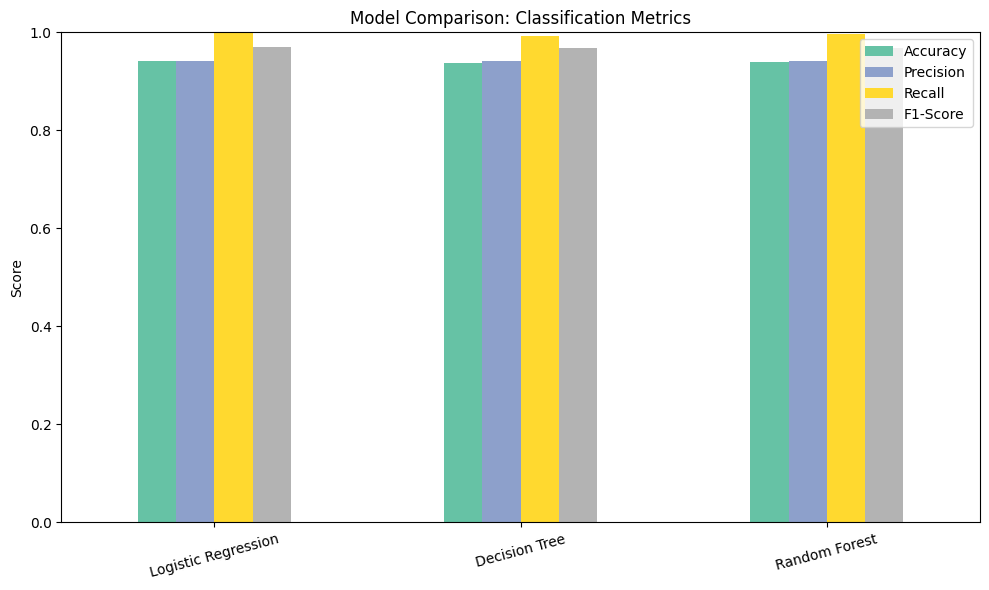

Plot saved.


In [13]:
# ── 6. Plot Model Comparison 
results_df.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Model Comparison: Classification Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()
print("Plot saved.")